# EDA

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import string
import re
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

#pip install pyldavis
import gensim
import pyLDAvis.gensim


[nltk_data] Downloading package punkt to /Users/foongming/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
# Load the dataset
data = pd.read_csv('newsapi_data.csv')

In [3]:
# Basic info about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   summary         209 non-null    object 
 1   image           203 non-null    object 
 2   sentiment       213 non-null    float64
 3   language        213 non-null    object 
 4   video           7 non-null      object 
 5   title           213 non-null    object 
 6   url             213 non-null    object 
 7   source_country  213 non-null    object 
 8   id              213 non-null    int64  
 9   text            213 non-null    object 
 10  publish_date    213 non-null    object 
 11  authors         196 non-null    object 
 12  category        89 non-null     object 
 13  Bias            213 non-null    object 
dtypes: float64(1), int64(1), object(12)
memory usage: 23.4+ KB


In [4]:
# Checking for missing values
missing_values = data.isnull().sum()
print(missing_values)

summary             4
image              10
sentiment           0
language            0
video             206
title               0
url                 0
source_country      0
id                  0
text                0
publish_date        0
authors            17
category          124
Bias                0
dtype: int64


In [5]:
# Drop rows where 'title', 'text', or 'Bias' are null
data = data.dropna(subset=['title', 'text', 'Bias'])

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   summary         209 non-null    object 
 1   image           203 non-null    object 
 2   sentiment       213 non-null    float64
 3   language        213 non-null    object 
 4   video           7 non-null      object 
 5   title           213 non-null    object 
 6   url             213 non-null    object 
 7   source_country  213 non-null    object 
 8   id              213 non-null    int64  
 9   text            213 non-null    object 
 10  publish_date    213 non-null    object 
 11  authors         196 non-null    object 
 12  category        89 non-null     object 
 13  Bias            213 non-null    object 
dtypes: float64(1), int64(1), object(12)
memory usage: 23.4+ KB


In [6]:
# Drop rows where the first word in 'text' is 'Advertisement'
data = data[~data['text'].str.strip().str.startswith('Advertisement')]

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188 entries, 0 to 212
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   summary         184 non-null    object 
 1   image           178 non-null    object 
 2   sentiment       188 non-null    float64
 3   language        188 non-null    object 
 4   video           7 non-null      object 
 5   title           188 non-null    object 
 6   url             188 non-null    object 
 7   source_country  188 non-null    object 
 8   id              188 non-null    int64  
 9   text            188 non-null    object 
 10  publish_date    188 non-null    object 
 11  authors         171 non-null    object 
 12  category        88 non-null     object 
 13  Bias            188 non-null    object 
dtypes: float64(1), int64(1), object(12)
memory usage: 22.0+ KB


In [7]:
def fix_encoding(text):
    # Fix common encoding issues

    text = (text
            .replace('Ã', 'A')
            .replace('Ã“', 'O')
            .replace('Ã§', 'c')
            .replace('Ã¢', 'a')
            .replace('Ã«', 'e')
            .replace('Ã¼', 'u')
            .replace('Ã¯', 'i')
            .replace('â€‘', '-')
            .replace('Ã', 'i')
            .replace('Ãº', 'u')
            .replace('â€‘', ' ')
            .replace('ðŸ¦Ž', ' ')
            .replace('Ã±', 'n')
            .replace('ðŸš¨', '')
            .replace('ðŸ”¥', '')
            .replace('Ã‰', '')
            .replace('â€‚', '')
            .replace('Ã¨', 'e')
            .replace('Ã©', 'e')
            .replace('â„¢', '')
            .replace('Ã¸', 'ø')
            .replace('\xad', '')
            .replace('Ã¡', 'a')
            .replace('Ã³','o')
            .replace('Ã¶', 'o')
            .replace('â€˜', "'")
            .replace('â€“', '-')
            .replace('â€”', '-')
            .replace('â€™', "'")
            .replace('â€œ', '"')
            .replace('â€', '"')
            .replace('â€™','"'))
    return text

## fix encoding issues
for col in ['title', 'text', 'Bias']:
    data[col] = data[col].apply(lambda x: fix_encoding(x))

## create helper columns
whitelist_pattern = r"[a-zA-Z\s0-9.$(),\'\":\-\?\[\]\!\%\&;\@\/\*\+\#ø£\=\_]"
t = data['text'].apply(lambda x: re.sub(whitelist_pattern, '', x))
data['special_symbol_length'] = t.str.len()
data['special_symbol_proportion'] = data['special_symbol_length'] / data['text'].str.len()
proportion = 0.0014

## filter out high proportions of special symbols - these are non english articles, they are all coming from Apnews source
data = data[~((data['special_symbol_proportion'] > proportion))]

## clean up text of special symbols
special_char_pattern = rf"[^{whitelist_pattern}]"
data['cleaned_text'] = data['text'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

def cols_to_string(data: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    for col in cols:
        data[col] = data[col].astype(str)
    return data

# Convert the data to strings 
data = cols_to_string(data, ['title', 'text', 'url', 'Bias'])

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, 6 to 200
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   summary                    50 non-null     object 
 1   image                      51 non-null     object 
 2   sentiment                  51 non-null     float64
 3   language                   51 non-null     object 
 4   video                      1 non-null      object 
 5   title                      51 non-null     object 
 6   url                        51 non-null     object 
 7   source_country             51 non-null     object 
 8   id                         51 non-null     int64  
 9   text                       51 non-null     object 
 10  publish_date               51 non-null     object 
 11  authors                    49 non-null     object 
 12  category                   25 non-null     object 
 13  Bias                       51 non-null     object 
 14  

In [8]:
data.describe()

,sentiment,id,special_symbol_length,special_symbol_proportion
count,51.000000,5.100000e+01,51.000000,51.000000
mean,0.043784,3.025634e+08,1.725490,0.000396
std,0.293781,5.365357e+06,2.417258,0.000435
min,-0.484000,2.967662e+08,0.000000,0.000000
25%,-0.164500,2.985086e+08,0.000000,0.000000
50%,0.033000,3.001916e+08,1.000000,0.000213
75%,0.222500,3.063688e+08,3.000000,0.000761
max,0.769000,3.150841e+08,13.000000,0.001283


In [9]:
# Define the mapping
bias_mapping = {
    'Least Biased': 'Center',
    'Left-Center': 'Lean Left',
    'Right-Center': 'Lean Right'
}

# Apply the mapping
data['Bias'] = data['Bias'].map(bias_mapping)

In [10]:
# Show the first few rows of the dataset
data.head()

,summary,image,sentiment,language,video,title,url,source_country,id,text,publish_date,authors,category,Bias,special_symbol_length,special_symbol_proportion,cleaned_text
6,The island’s relationships with both Denmark a...,https://static.independent.co.uk/2025/03/10/06...,0.293,en,https://cdn.jwplayer.com/videos/yeVQYSPm-4VHSa...,How Donald Trump could benefit from Greenland’...,https://www.independent.co.uk/news/world/ameri...,gb,298906820,Greenland is holding a general election on Mar...,2025-03-11 07:07:59,"['Jacob Gronholt-Pedersen', 'Stine Jacobsen an...",politics,Lean Left,2,0.000338,Greenland is holding a general election on Mar...
11,"India's spin quartet, led by Kuldeep Yadav, ha...","https://static.toiimg.com/thumb/resizemode-4,w...",0.068,en,NaN,"Spin, strangle, conquer: India's quartet choke...",https://timesofindia.indiatimes.com/sports/cri...,IN,298321806,"TimesofIndia.com in Dubai: Eat, sleep, spin ch...",2025-03-09 13:05:53,['SAHIL MALHOTRA'],sports,Lean Right,0,0.000000,TimesofIndiacom in Dubai Eat sleep spin choke ...
12,Shreyas Iyer celebrated India's Champions Trop...,"https://static.toiimg.com/thumb/resizemode-4,w...",0.108,en,NaN,"Exclusive: 'Koi bhi situation mei bhejo, karke...",https://timesofindia.indiatimes.com/sports/cri...,IN,298885802,TimesofIndia.com in Dubai: The 2025 Champions ...,2025-03-11 05:55:59,['SAHIL MALHOTRA'],politics,Lean Right,4,0.000525,TimesofIndiacom in Dubai The Champions Trophy...
13,New Zealand and India prepare for the Champion...,"https://static.toiimg.com/thumb/resizemode-4,w...",0.088,en,NaN,Champions Trophy: New Zealand better prepped t...,https://timesofindia.indiatimes.com/sports/cri...,IN,297416890,TimesofIndia.com in Dubai: Karachi to Rawalpin...,2025-03-06 16:06:06,['SAHIL MALHOTRA'],sports,Lean Right,0,0.000000,TimesofIndiacom in Dubai Karachi to Rawalpindi...
15,"In Dubai, Indian cricketers underwent a light ...","https://static.toiimg.com/thumb/resizemode-4,w...",0.033,en,NaN,"The Rohit Sharma conundrum: Eye on the prize, ...",https://timesofindia.indiatimes.com/sports/cri...,IN,298109858,"TimesofIndia.com in Dubai: ""Macha come for fiv...",2025-03-08 16:51:47,['SAHIL MALHOTRA'],NaN,Lean Right,0,0.000000,TimesofIndiacom in Dubai Macha come for five m...


In [11]:
# same as original data EDA 
data = data.drop_duplicates(subset='title', keep='first')
data = data.drop_duplicates(subset='text', keep='first')
data = data.drop_duplicates(subset='url', keep='first')

In [12]:
# Verify by checking the data info
data.describe()

,sentiment,id,special_symbol_length,special_symbol_proportion
count,51.000000,5.100000e+01,51.000000,51.000000
mean,0.043784,3.025634e+08,1.725490,0.000396
std,0.293781,5.365357e+06,2.417258,0.000435
min,-0.484000,2.967662e+08,0.000000,0.000000
25%,-0.164500,2.985086e+08,0.000000,0.000000
50%,0.033000,3.001916e+08,1.000000,0.000213
75%,0.222500,3.063688e+08,3.000000,0.000761
max,0.769000,3.150841e+08,13.000000,0.001283


## Distribution of Bias over dataset

In [13]:
# Checking the distribution of the 'Bias' column
bias_counts = data['Bias'].value_counts()
print(bias_counts)
# over representation of left bias

Bias
Lean Left     29
Center        12
Lean Right    10
Name: count, dtype: int64


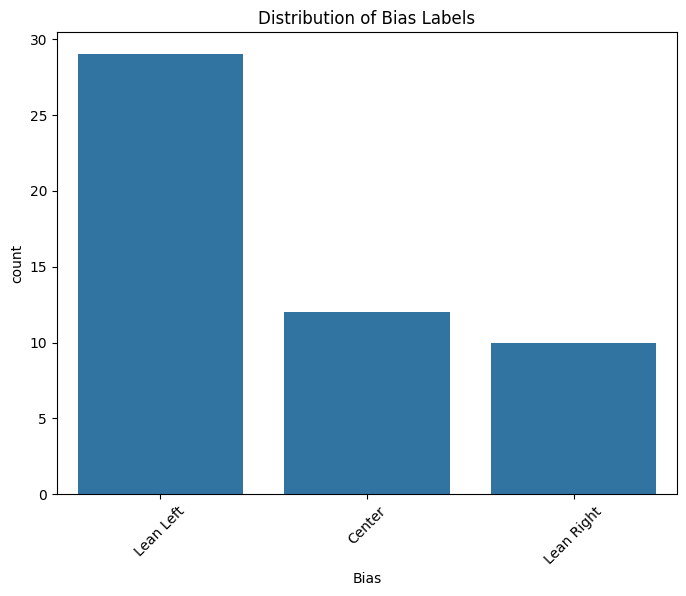

In [14]:
# Visualizing the distribution of Bias labels
plt.figure(figsize=(8,6))
sns.countplot(data=data, x='Bias', order=data['Bias'].value_counts().index)
plt.title('Distribution of Bias Labels')
plt.xticks(rotation=45)
plt.show()

In [15]:
# Here we remove source name from article text so as to remove the predictors from the text
# This allows our model to generalise to sources outside the training data 

# We also know that news articles then to cite other sources in their articles. this removal also address this conflating factor

# Define regex patterns for each source name.
# These patterns account for optional spaces between words.
source_patterns = [
    r'\bAlternet\b',
    r'\bAP\s*News\b',                   # Matches "APNews" or "AP News"
    r'\bBlaze\s*Media\b',
    r'\bBreit\s*Bart\b',
    r'\bHuff\s*post\b',                  # Matches "Huffpost" or "Huff post"
    r'\bIndependent\s*Journal\s*Review\b',
    r'\bMother\s*Jones\b',
    r'\bNew\s*York\s*Post\b',
    r'\bStraight\s*Arrow\s*News\b',
    r'\bThe\s*Daily\s*Beast\b',
    r'\bThe\s*Dispatch\b',
    r'\bThe\s*Federalist\b',
    r'\bThe\s*Free\s*Press\b',
    r'\bThe\s*Nation\b',
    r'\bThe\s*Washington\s*Free\s*Beacon\b',
    r'\babc\s*news\b',
    r'\bcnbc\b',
    r'\bnbc\s*news\b',
    r'\bnpr\b',
    r'\busa\s*today\b'
]

# Combine the individual patterns into one regex pattern.
combined_pattern = re.compile("|".join(source_patterns), flags=re.IGNORECASE)

def remove_source_names(text):
    """
    Removes occurrences of known source names from the input text using the combined regex.
    """
    # Replace any match with an empty string
    return combined_pattern.sub("", text)

# create a copy to store the modified text
df_stripped = data.copy()

# Apply the removal function to the 'Text' column
df_stripped['stripped_text'] = df_stripped['text'].apply(remove_source_names)

# calculate word counts before and after source removal
df_stripped['Text_length'] = df_stripped['text'].apply(lambda x: len(x.split()))
df_stripped['stripped_len'] = df_stripped['stripped_text'].apply(lambda x: len(x.split()))
df_stripped['text_length_diff'] = df_stripped['Text_length'] - df_stripped['stripped_len']

In [16]:
# Display the first few rows of the new DataFrame.
df_stripped.head()

,summary,image,sentiment,language,video,title,url,source_country,id,text,...,authors,category,Bias,special_symbol_length,special_symbol_proportion,cleaned_text,stripped_text,Text_length,stripped_len,text_length_diff
6,The island’s relationships with both Denmark a...,https://static.independent.co.uk/2025/03/10/06...,0.293,en,https://cdn.jwplayer.com/videos/yeVQYSPm-4VHSa...,How Donald Trump could benefit from Greenland’...,https://www.independent.co.uk/news/world/ameri...,gb,298906820,Greenland is holding a general election on Mar...,...,"['Jacob Gronholt-Pedersen', 'Stine Jacobsen an...",politics,Lean Left,2,0.000338,Greenland is holding a general election on Mar...,Greenland is holding a general election on Mar...,896,896,0
11,"India's spin quartet, led by Kuldeep Yadav, ha...","https://static.toiimg.com/thumb/resizemode-4,w...",0.068,en,NaN,"Spin, strangle, conquer: India's quartet choke...",https://timesofindia.indiatimes.com/sports/cri...,IN,298321806,"TimesofIndia.com in Dubai: Eat, sleep, spin ch...",...,['SAHIL MALHOTRA'],sports,Lean Right,0,0.000000,TimesofIndiacom in Dubai Eat sleep spin choke ...,"TimesofIndia.com in Dubai: Eat, sleep, spin ch...",671,671,0
12,Shreyas Iyer celebrated India's Champions Trop...,"https://static.toiimg.com/thumb/resizemode-4,w...",0.108,en,NaN,"Exclusive: 'Koi bhi situation mei bhejo, karke...",https://timesofindia.indiatimes.com/sports/cri...,IN,298885802,TimesofIndia.com in Dubai: The 2025 Champions ...,...,['SAHIL MALHOTRA'],politics,Lean Right,4,0.000525,TimesofIndiacom in Dubai The Champions Trophy...,TimesofIndia.com in Dubai: The 2025 Champions ...,1364,1364,0
13,New Zealand and India prepare for the Champion...,"https://static.toiimg.com/thumb/resizemode-4,w...",0.088,en,NaN,Champions Trophy: New Zealand better prepped t...,https://timesofindia.indiatimes.com/sports/cri...,IN,297416890,TimesofIndia.com in Dubai: Karachi to Rawalpin...,...,['SAHIL MALHOTRA'],sports,Lean Right,0,0.000000,TimesofIndiacom in Dubai Karachi to Rawalpindi...,TimesofIndia.com in Dubai: Karachi to Rawalpin...,730,730,0
15,"In Dubai, Indian cricketers underwent a light ...","https://static.toiimg.com/thumb/resizemode-4,w...",0.033,en,NaN,"The Rohit Sharma conundrum: Eye on the prize, ...",https://timesofindia.indiatimes.com/sports/cri...,IN,298109858,"TimesofIndia.com in Dubai: ""Macha come for fiv...",...,['SAHIL MALHOTRA'],NaN,Lean Right,0,0.000000,TimesofIndiacom in Dubai Macha come for five m...,"TimesofIndia.com in Dubai: ""Macha come for fiv...",652,652,0


In [17]:
# Calculate the average number of words removed per article
average_words_removed = df_stripped['text_length_diff'].mean()
print("Average number of words removed per article:", average_words_removed)

Average number of words removed per article: 0.49019607843137253


In [18]:
# Count the number of rows with text removed
num_articles_removed = df_stripped[df_stripped['text_length_diff'] > 0].shape[0]

# Total number of articles
total_articles = df_stripped.shape[0]

# Calculate the percentage of articles with text removed
percentage_removed = (num_articles_removed / total_articles) * 100

print("Number of articles with text removed:", num_articles_removed)
print("Percentage of articles with text removed: {:.2f}%".format(percentage_removed))

Number of articles with text removed: 6
Percentage of articles with text removed: 11.76%


## Analyse Length

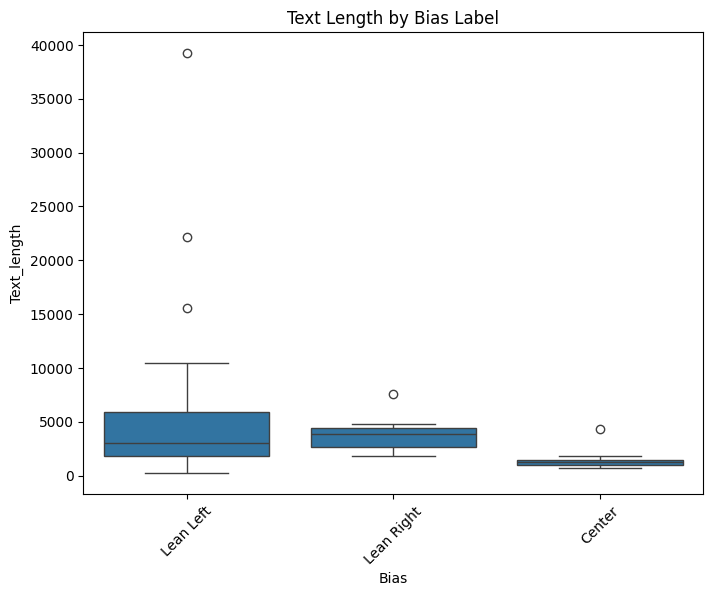

In [19]:
# Investigating length of articles by bias
data['Text_length'] = data['text'].apply(len)

plt.figure(figsize=(8,6))
sns.boxplot(data=data, x='Bias', y='Text_length')
plt.title('Text Length by Bias Label')
plt.xticks(rotation=45)
plt.show()

In [20]:
# Group by 'Bias' and get text length analysis for each group
grouped_description = data.groupby('Bias').describe()

# Display the result
print(grouped_description)

           sentiment                                                      \
               count      mean       std    min      25%     50%     75%   
Bias                                                                       
Center          12.0 -0.018750  0.296512 -0.355 -0.22025 -0.0705  0.1195   
Lean Left       29.0  0.092966  0.303791 -0.484 -0.13400  0.1340  0.2930   
Lean Right      10.0 -0.023800  0.258502 -0.403 -0.23925  0.0505  0.1030   

                     id                ... special_symbol_proportion  \
              max count          mean  ...                       75%   
Bias                                   ...                             
Center      0.724  12.0  3.066485e+08  ...                  0.000000   
Lean Left   0.769  29.0  2.999502e+08  ...                  0.000834   
Lean Right  0.465  10.0  3.052397e+08  ...                  0.000874   

                     Text_length                                            \
                 max       count

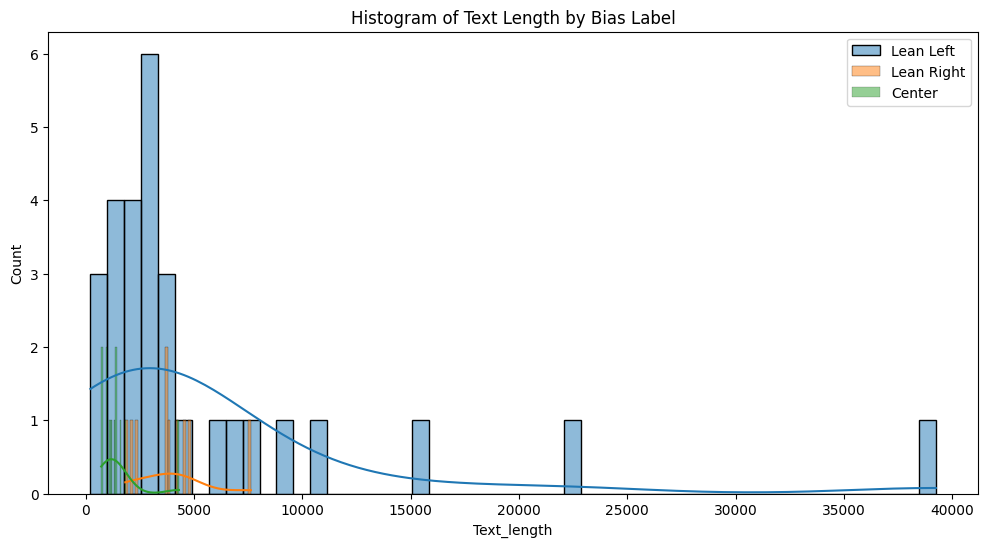

In [21]:
plt.figure(figsize=(12,6))
for bias_label in data['Bias'].unique():
    sns.histplot(data[data['Bias'] == bias_label]['Text_length'], kde=True, label=bias_label, bins=50)
plt.legend()
plt.title("Histogram of Text Length by Bias Label")
plt.show()

## Analyse Distribution of Vocabulary

In [22]:
# Dictionary to store unique word count for each Bias label
unique_word_counts = {}

# Iterate through unique Bias labels
for bias_label in df_stripped['Bias'].unique():
    # Concatenate all text for the current bias label
    all_text = " ".join(df_stripped[df_stripped['Bias'] == bias_label]['text'])
    
    # Get unique words
    unique_words = set(all_text.split())
    
    # Store the count in the dictionary
    unique_word_counts[bias_label] = len(unique_words)

# Sort the dictionary by values in descending order
sorted_unique_word_counts = dict(sorted(unique_word_counts.items(), key=lambda item: item[1], reverse=True))

# Print the sorted dictionary
print(sorted_unique_word_counts)

{'Lean Left': 6631, 'Lean Right': 2491, 'Center': 1265}


In [23]:
# Function to compute unique word count for each row
def unique_word_count(text):
    return len(set(str(text).split()))

# Add a new column for per-row unique word count
df_stripped['unique_word_count'] = df_stripped['stripped_text'].apply(unique_word_count)

# Display the first few rows of the updated DataFrame
df_stripped.head()

,summary,image,sentiment,language,video,title,url,source_country,id,text,...,category,Bias,special_symbol_length,special_symbol_proportion,cleaned_text,stripped_text,Text_length,stripped_len,text_length_diff,unique_word_count
6,The island’s relationships with both Denmark a...,https://static.independent.co.uk/2025/03/10/06...,0.293,en,https://cdn.jwplayer.com/videos/yeVQYSPm-4VHSa...,How Donald Trump could benefit from Greenland’...,https://www.independent.co.uk/news/world/ameri...,gb,298906820,Greenland is holding a general election on Mar...,...,politics,Lean Left,2,0.000338,Greenland is holding a general election on Mar...,Greenland is holding a general election on Mar...,896,896,0,480
11,"India's spin quartet, led by Kuldeep Yadav, ha...","https://static.toiimg.com/thumb/resizemode-4,w...",0.068,en,NaN,"Spin, strangle, conquer: India's quartet choke...",https://timesofindia.indiatimes.com/sports/cri...,IN,298321806,"TimesofIndia.com in Dubai: Eat, sleep, spin ch...",...,sports,Lean Right,0,0.000000,TimesofIndiacom in Dubai Eat sleep spin choke ...,"TimesofIndia.com in Dubai: Eat, sleep, spin ch...",671,671,0,366
12,Shreyas Iyer celebrated India's Champions Trop...,"https://static.toiimg.com/thumb/resizemode-4,w...",0.108,en,NaN,"Exclusive: 'Koi bhi situation mei bhejo, karke...",https://timesofindia.indiatimes.com/sports/cri...,IN,298885802,TimesofIndia.com in Dubai: The 2025 Champions ...,...,politics,Lean Right,4,0.000525,TimesofIndiacom in Dubai The Champions Trophy...,TimesofIndia.com in Dubai: The 2025 Champions ...,1364,1364,0,621
13,New Zealand and India prepare for the Champion...,"https://static.toiimg.com/thumb/resizemode-4,w...",0.088,en,NaN,Champions Trophy: New Zealand better prepped t...,https://timesofindia.indiatimes.com/sports/cri...,IN,297416890,TimesofIndia.com in Dubai: Karachi to Rawalpin...,...,sports,Lean Right,0,0.000000,TimesofIndiacom in Dubai Karachi to Rawalpindi...,TimesofIndia.com in Dubai: Karachi to Rawalpin...,730,730,0,381
15,"In Dubai, Indian cricketers underwent a light ...","https://static.toiimg.com/thumb/resizemode-4,w...",0.033,en,NaN,"The Rohit Sharma conundrum: Eye on the prize, ...",https://timesofindia.indiatimes.com/sports/cri...,IN,298109858,"TimesofIndia.com in Dubai: ""Macha come for fiv...",...,NaN,Lean Right,0,0.000000,TimesofIndiacom in Dubai Macha come for five m...,"TimesofIndia.com in Dubai: ""Macha come for fiv...",652,652,0,369


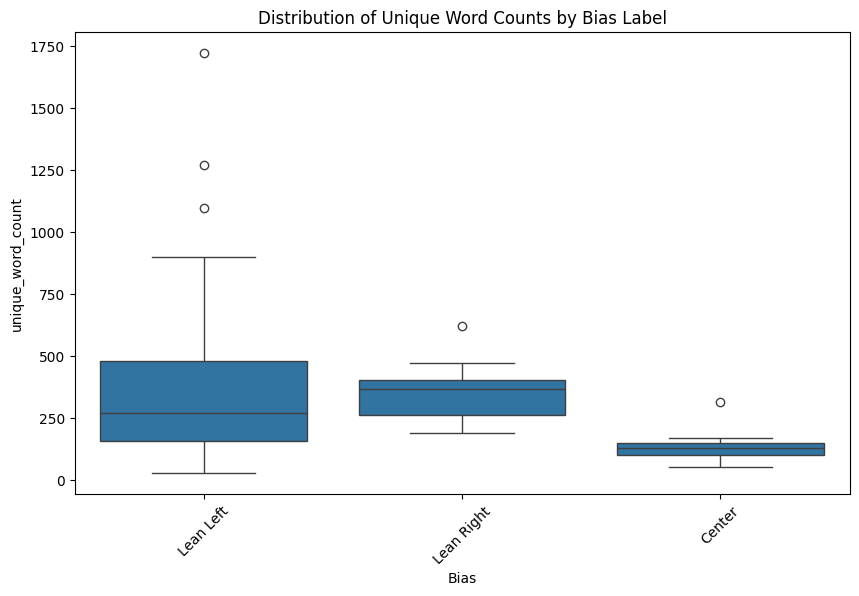

In [24]:
# Visualize distributions
plt.figure(figsize=(10,6))
sns.boxplot(x=data['Bias'], y=df_stripped['unique_word_count'])
plt.xticks(rotation=45)
plt.title("Distribution of Unique Word Counts by Bias Label")
plt.show()

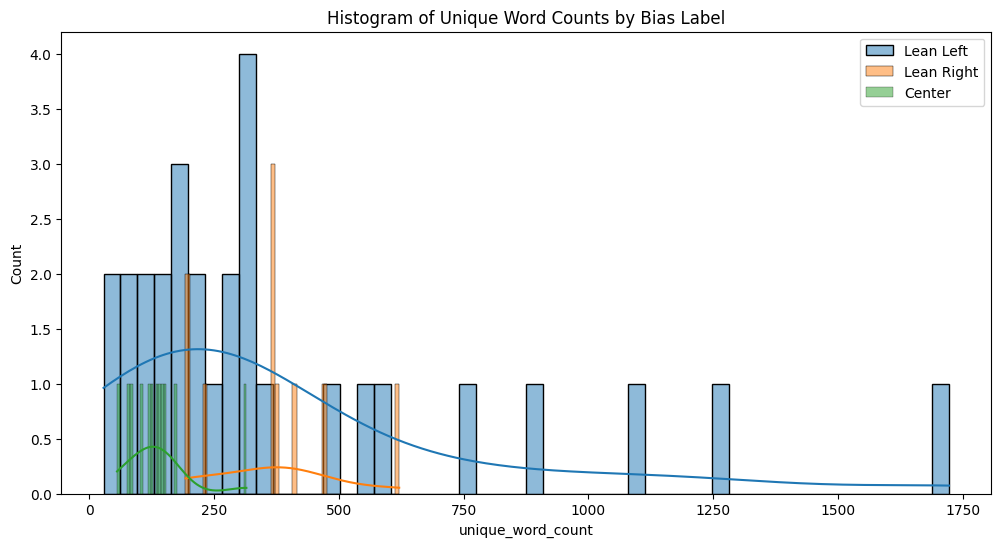

In [25]:
plt.figure(figsize=(12,6))
for bias_label in df_stripped['Bias'].unique():
    sns.histplot(df_stripped[df_stripped['Bias'] == bias_label]['unique_word_count'], kde=True, label=bias_label, bins=50)
plt.legend()
plt.title("Histogram of Unique Word Counts by Bias Label")
plt.show()

## Analyse Text Content 

In [26]:
# Define a set of English stopwords
stop_words = set(stopwords.words('english'))

def clean_and_stem_text(text):
    """
    Clean, remove stopwords, and stem text.
    
    Steps:
    1. Convert text to lowercase.
    2. Remove punctuation and non-alphabetic characters.
    3. Tokenize the text.
    4. Remove stopwords.
    5. Apply stemming on each token.
    6. Rejoin tokens into a cleaned string.
    """
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation and non-letter characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize the text into words
    tokens = nltk.word_tokenize(text)
    
    # Remove stopwords
    tokens = [token for token in tokens if token not in stop_words]
    
    # Initialize the stemmer
    stemmer = PorterStemmer()
    
    # Stem each token
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    
    # Rejoin the stemmed tokens into a single string
    cleaned_text = ' '.join(stemmed_tokens)
    return cleaned_text

# Example usage:
sample_text = "Running, runners ran and are running quickly! But they weren't too happy about it."
print(clean_and_stem_text(sample_text))

run runner ran run quickli werent happi


In [27]:
# Apply the clean_text function to the 'Text' column
df_stripped['cleaned_text'] = df_stripped['stripped_text'].apply(clean_and_stem_text)

# Most common words (excluding stopwords)
words = ' '.join(df_stripped['cleaned_text']).split()
word_counts = Counter(words)
most_common_words = word_counts.most_common(20)

# Display the 20 most common words
common_words_df = pd.DataFrame(most_common_words, columns=['Word', 'Frequency'])
common_words_df

,Word,Frequency
0,week,130
1,us,124
2,like,109
3,march,96
4,peopl,92
5,car,92
6,get,91
7,said,90
8,go,89
9,state,85


In [28]:
df_stripped

,summary,image,sentiment,language,video,title,url,source_country,id,text,...,category,Bias,special_symbol_length,special_symbol_proportion,cleaned_text,stripped_text,Text_length,stripped_len,text_length_diff,unique_word_count
6,The island’s relationships with both Denmark a...,https://static.independent.co.uk/2025/03/10/06...,0.293,en,https://cdn.jwplayer.com/videos/yeVQYSPm-4VHSa...,How Donald Trump could benefit from Greenland’...,https://www.independent.co.uk/news/world/ameri...,gb,298906820,Greenland is holding a general election on Mar...,...,politics,Lean Left,2,0.000338,greenland hold gener elect march week presid d...,Greenland is holding a general election on Mar...,896,896,0,480
11,"India's spin quartet, led by Kuldeep Yadav, ha...","https://static.toiimg.com/thumb/resizemode-4,w...",0.068,en,NaN,"Spin, strangle, conquer: India's quartet choke...",https://timesofindia.indiatimes.com/sports/cri...,IN,298321806,"TimesofIndia.com in Dubai: Eat, sleep, spin ch...",...,sports,Lean Right,0,0.000000,timesofindiacom dubai eat sleep spin choke rep...,"TimesofIndia.com in Dubai: Eat, sleep, spin ch...",671,671,0,366
12,Shreyas Iyer celebrated India's Champions Trop...,"https://static.toiimg.com/thumb/resizemode-4,w...",0.108,en,NaN,"Exclusive: 'Koi bhi situation mei bhejo, karke...",https://timesofindia.indiatimes.com/sports/cri...,IN,298885802,TimesofIndia.com in Dubai: The 2025 Champions ...,...,politics,Lean Right,4,0.000525,timesofindiacom dubai champion trophi winner m...,TimesofIndia.com in Dubai: The 2025 Champions ...,1364,1364,0,621
13,New Zealand and India prepare for the Champion...,"https://static.toiimg.com/thumb/resizemode-4,w...",0.088,en,NaN,Champions Trophy: New Zealand better prepped t...,https://timesofindia.indiatimes.com/sports/cri...,IN,297416890,TimesofIndia.com in Dubai: Karachi to Rawalpin...,...,sports,Lean Right,0,0.000000,timesofindiacom dubai karachi rawalpindi dubai...,TimesofIndia.com in Dubai: Karachi to Rawalpin...,730,730,0,381
15,"In Dubai, Indian cricketers underwent a light ...","https://static.toiimg.com/thumb/resizemode-4,w...",0.033,en,NaN,"The Rohit Sharma conundrum: Eye on the prize, ...",https://timesofindia.indiatimes.com/sports/cri...,IN,298109858,"TimesofIndia.com in Dubai: ""Macha come for fiv...",...,NaN,Lean Right,0,0.000000,timesofindiacom dubai macha come five minut na...,"TimesofIndia.com in Dubai: ""Macha come for fiv...",652,652,0,369
19,Three youths were arrested by Kattoor police i...,"https://static.toiimg.com/thumb/resizemode-72,...",-0.260,en,NaN,"Liquor bottles, threats and theft: Coimbatore ...",https://timesofindia.indiatimes.com/city/coimb...,IN,303641584,COIMBATORE: Kattoor police in Coimbatore city ...,...,NaN,Lean Right,2,0.000954,coimbator kattoor polic coimbator citi arrest ...,COIMBATORE: Kattoor police in Coimbatore city ...,345,345,0,193
31,The Petroleum Products Retail Outlet Owners As...,https://dailypost.ng/wp-content/uploads/2023/0...,0.185,en,NaN,"Marketers lost billions to NNPC, Dangote’s fue...",https://dailypost.ng/2025/03/10/marketers-lost...,ng,298678658,The Petroleum Products Retail Outlet Owners As...,...,politics,Center,0,0.000000,petroleum product retail outlet owner associ s...,The Petroleum Products Retail Outlet Owners As...,595,595,0,315
32,"The Minister of Federal Capital Territory, Nye...",https://dailypost.ng/wp-content/uploads/2023/1...,-0.145,en,NaN,Rivers Crisis: Fubara surrounds himself with t...,https://dailypost.ng/2025/03/15/rivers-crisis-...,ng,300545748,"The Minister of Federal Capital Territory, Nye...",...,politics,Center,0,0.000000,minist feder capit territori nyesom wike said ...,"The Minister of Federal Capital Territory, Nye...",202,202,0,148
34,The Presidential Candidate of African Action C...,https://dailypost.ng/wp-content/uploads/2024/1...,-0.212,en,NaN,Rivers: Why I’m happy with Tinubu’s state of e...,https://dailypost.ng/2025/03/20/rivers-why-im-...,ng,302124244,The Presidential Candidate of African Action C...,...,

In [29]:
total_words = sum(word_counts.values())
print(total_words)

20723


In [30]:
common_words_df['Percentage'] = (common_words_df['Frequency'] / total_words) * 100

In [31]:
common_words_df.head(20)

,Word,Frequency,Percentage
0,week,130,0.627322
1,us,124,0.598369
2,like,109,0.525986
3,march,96,0.463253
4,peopl,92,0.443951
5,car,92,0.443951
6,get,91,0.439126
7,said,90,0.434300
8,go,89,0.429474
9,state,85,0.410172


In [32]:
# Check types of entries in the 'cleaned_text' column
non_string_entries = df_stripped[~df_stripped['cleaned_text'].apply(lambda x: isinstance(x, str))]
print("Non-string entries found:")
print(non_string_entries[['cleaned_text', 'Bias']])

Non-string entries found:
Empty DataFrame
Columns: [cleaned_text, Bias]
Index: []


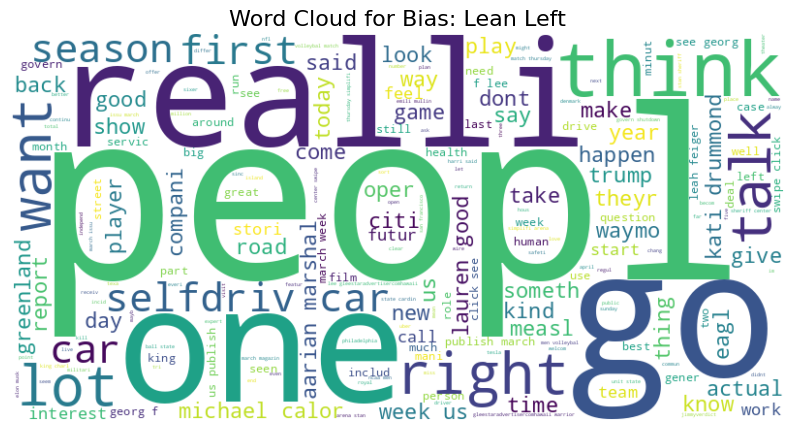

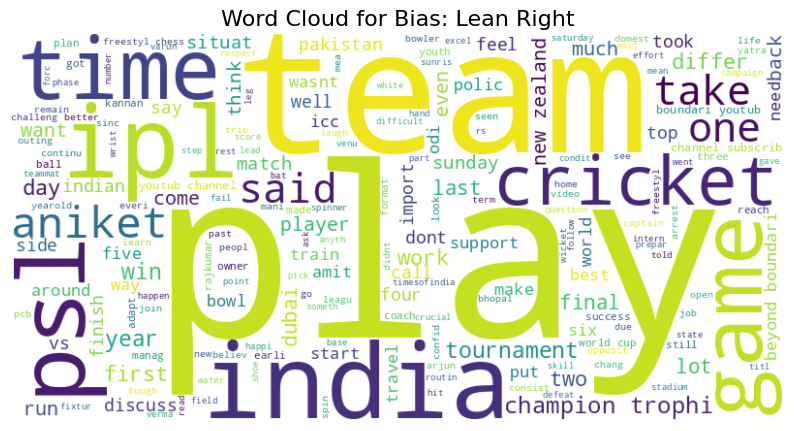

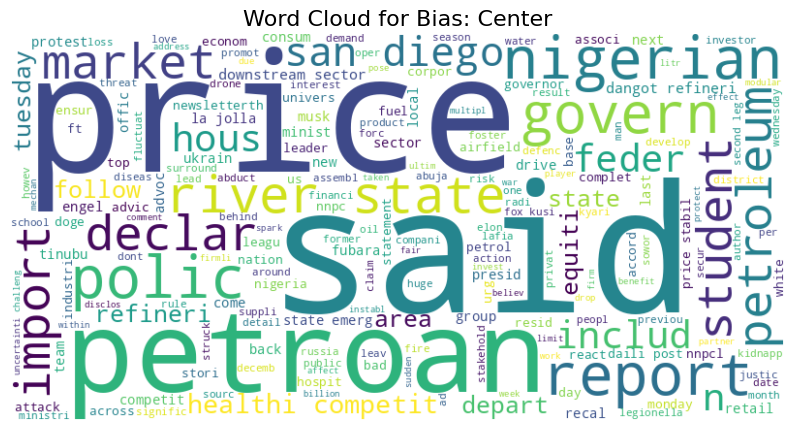

In [33]:
# Get unique bias values
biases = df_stripped['Bias'].unique()

# Iterate over each bias and generate a word cloud
for bias in biases:
    # Filter the DataFrame for the current bias
    bias_text = ' '.join(df_stripped[df_stripped['Bias'] == bias]['cleaned_text'])
    
    # Generate the word cloud for the current bias
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(bias_text)
    
    # Plot the word cloud
    plt.figure(figsize=(10, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for Bias: {bias}', fontsize=16)
    plt.axis('off')
    plt.show()

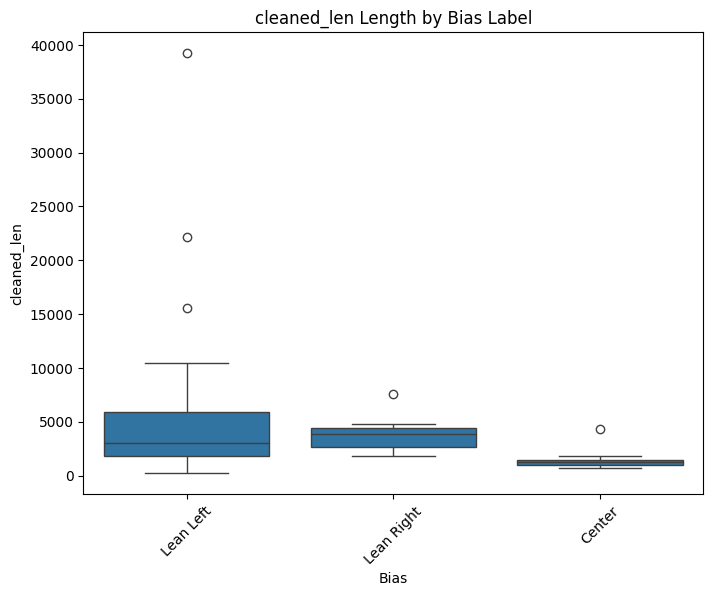

In [34]:
# Investigating length of cleaned articles by bias
df_stripped['cleaned_len'] = df_stripped['text'].apply(len)

plt.figure(figsize=(8,6))
sns.boxplot(data=df_stripped, x='Bias', y='cleaned_len')
plt.title('cleaned_len Length by Bias Label')
plt.xticks(rotation=45)
plt.show()

In [35]:
# Define stopwords set
stop = set(stopwords.words('english'))

def preprocess_text(text):
    corpus = []
    lem = WordNetLemmatizer()
    for news in text:
        # Ensure each news item is a string before tokenizing
        #news_str = str(news)
        words = [w for w in word_tokenize(news) if w.lower() not in stop] #check if this is redundant 
        words = [lem.lemmatize(w) for w in words if len(w) > 2]
        corpus.append(words)
    return corpus

def get_lda_by_bias(data):
    lda_models = {}
    bow_corpus_dict = {}

    for bias_label in data['Bias'].unique():
        # Use data passed to the function instead of df_stripped directly for consistency
        subset = data[data['Bias'] == bias_label]['cleaned_text'].dropna().tolist()
        corpus = preprocess_text(subset)

        dic = gensim.corpora.Dictionary(corpus)
        bow_corpus = [dic.doc2bow(doc) for doc in corpus]

        lda_model = gensim.models.LdaMulticore(
            bow_corpus, num_topics=4, id2word=dic, passes=10, workers=2
        )

        lda_models[bias_label] = lda_model
        bow_corpus_dict[bias_label] = (bow_corpus, dic)

    return lda_models, bow_corpus_dict

def plot_lda_vis(lda_model, bow_corpus, dic):
    pyLDAvis.enable_notebook()
    vis = pyLDAvis.gensim.prepare(lda_model, bow_corpus, dic)
    return vis

def show_topics_by_bias(lda_models):
    for bias_label, lda_model in lda_models.items():
        print(f"\nTopics for Bias: {bias_label}")
        topics = lda_model.print_topics(num_words=5)
        for topic in topics:
            print(topic)

In [36]:
df_stripped

,summary,image,sentiment,language,video,title,url,source_country,id,text,...,Bias,special_symbol_length,special_symbol_proportion,cleaned_text,stripped_text,Text_length,stripped_len,text_length_diff,unique_word_count,cleaned_len
6,The island’s relationships with both Denmark a...,https://static.independent.co.uk/2025/03/10/06...,0.293,en,https://cdn.jwplayer.com/videos/yeVQYSPm-4VHSa...,How Donald Trump could benefit from Greenland’...,https://www.independent.co.uk/news/world/ameri...,gb,298906820,Greenland is holding a general election on Mar...,...,Lean Left,2,0.000338,greenland hold gener elect march week presid d...,Greenland is holding a general election on Mar...,896,896,0,480,5923
11,"India's spin quartet, led by Kuldeep Yadav, ha...","https://static.toiimg.com/thumb/resizemode-4,w...",0.068,en,NaN,"Spin, strangle, conquer: India's quartet choke...",https://timesofindia.indiatimes.com/sports/cri...,IN,298321806,"TimesofIndia.com in Dubai: Eat, sleep, spin ch...",...,Lean Right,0,0.000000,timesofindiacom dubai eat sleep spin choke rep...,"TimesofIndia.com in Dubai: Eat, sleep, spin ch...",671,671,0,366,3775
12,Shreyas Iyer celebrated India's Champions Trop...,"https://static.toiimg.com/thumb/resizemode-4,w...",0.108,en,NaN,"Exclusive: 'Koi bhi situation mei bhejo, karke...",https://timesofindia.indiatimes.com/sports/cri...,IN,298885802,TimesofIndia.com in Dubai: The 2025 Champions ...,...,Lean Right,4,0.000525,timesofindiacom dubai champion trophi winner m...,TimesofIndia.com in Dubai: The 2025 Champions ...,1364,1364,0,621,7620
13,New Zealand and India prepare for the Champion...,"https://static.toiimg.com/thumb/resizemode-4,w...",0.088,en,NaN,Champions Trophy: New Zealand better prepped t...,https://timesofindia.indiatimes.com/sports/cri...,IN,297416890,TimesofIndia.com in Dubai: Karachi to Rawalpin...,...,Lean Right,0,0.000000,timesofindiacom dubai karachi rawalpindi dubai...,TimesofIndia.com in Dubai: Karachi to Rawalpin...,730,730,0,381,4205
15,"In Dubai, Indian cricketers underwent a light ...","https://static.toiimg.com/thumb/resizemode-4,w...",0.033,en,NaN,"The Rohit Sharma conundrum: Eye on the prize, ...",https://timesofindia.indiatimes.com/sports/cri...,IN,298109858,"TimesofIndia.com in Dubai: ""Macha come for fiv...",...,Lean Right,0,0.000000,timesofindiacom dubai macha come five minut na...,"TimesofIndia.com in Dubai: ""Macha come for fiv...",652,652,0,369,3762
19,Three youths were arrested by Kattoor police i...,"https://static.toiimg.com/thumb/resizemode-72,...",-0.260,en,NaN,"Liquor bottles, threats and theft: Coimbatore ...",https://timesofindia.indiatimes.com/city/coimb...,IN,303641584,COIMBATORE: Kattoor police in Coimbatore city ...,...,Lean Right,2,0.000954,coimbator kattoor polic coimbator citi arrest ...,COIMBATORE: Kattoor police in Coimbatore city ...,345,345,0,193,2096
31,The Petroleum Products Retail Outlet Owners As...,https://dailypost.ng/wp-content/uploads/2023/0...,0.185,en,NaN,"Marketers lost billions to NNPC, Dangote’s fue...",https://dailypost.ng/2025/03/10/marketers-lost...,ng,298678658,The Petroleum Products Retail Outlet Owners As...,...,Center,0,0.000000,petroleum product retail outlet owner associ s...,The Petroleum Products Retail Outlet Owners As...,595,595,0,315,4298
32,"The Minister of Federal Capital Territory, Nye...",https://dailypost.ng/wp-content/uploads/2023/1...,-0.145,en,NaN,Rivers Crisis: Fubara surrounds himself with t...,https://dailypost.ng/2025/03/15/rivers-crisis-...,ng,300545748,"The Minister of Federal Capital Territory, Nye...",...,Center,0,0.000000,minist feder capit territori nyesom wike said ...,"The Minister of Federal Capital Territory, Nye...",202,202,0,148,1379
34,The Presidential Candidate of African Action C...,https://dailypost.ng/wp-content/uploads/2024/1...,-0.212,en,NaN,Rivers: Why I’m happy with Tinubu’s state of e...,https://dailypost.ng/2025/03/20/rivers-why-im-...,ng,302124244,The Presidential Candidate of African Action C...,...,Center,0,0.0000

In [37]:
subset = df_stripped[df_stripped['Bias'] == bias_label]['cleaned_text'].dropna().tolist()
print(subset)

['petroleum product retail outlet owner associ said petrol market lost billion due downward review fuel price nigerian nation petroleum compani limit dangot refineri petroan spokesman joseph obel disclos monday comment need healthi competit price stabil within nigeria petroleum downstream sector recal last week monday nnpc drop retail petrol price n n per litr n n lago abuja respect nnpc petrol price drop follow dangot refineri retail fuel price reduct n n per litr across retail partner develop spark fresh price war nnpcl dangot refineri react fluctuat price instabl petroan recommend sixmonth price stabil mechan petroan firmli commit petroleum industri stakehold forum stand firm advoc healthi competit full liberalis price stabil downstream sector urgent urg nmdpra quickli swing action ensur fair price believ work togeth industri stakehold govern consum creat vibrant competit market benefit everyon averag citizen sudden spike fuel price lead financi strain uncertainti associ stress sudd

In [38]:
from sklearn.model_selection import train_test_split

# take only cols of interest 
df_final = df_stripped[['title', 'cleaned_text', 'Bias']].copy()
#rename
df_final = df_final.rename(columns={'title': 'Title'})
#df_final = df_final.rename(columns={'cleaned_text': 'Text'})


# Split the data with 'Bias' as target
train, test = train_test_split(df_final, test_size=0.2, random_state=42, stratify=df_final['Bias'])

# Save the splits for later use
train.to_csv('newsapi_train_preprocessed.csv', index=False)
test.to_csv('newsapi_test_preprocessed.csv', index=False)

In [39]:
print(train.shape)
print(test.shape)

(40, 3)
(11, 3)


In [40]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, 6 to 200
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         51 non-null     object
 1   cleaned_text  51 non-null     object
 2   Bias          51 non-null     object
dtypes: object(3)
memory usage: 1.6+ KB


# For BERT and other similar models, we can retain punctuations, and numbers.

In [41]:
from sklearn.model_selection import train_test_split
data = pd.read_csv('newsapi_data.csv')

# repeat same cleaning
data = data.dropna(subset=['title', 'text', 'Bias'])
data = data[~data['text'].str.strip().str.startswith('Advertisement')]

# same as original data EDA 
data = data.drop_duplicates(subset='title', keep='first')
data = data.drop_duplicates(subset='text', keep='first')
data = data.drop_duplicates(subset='url', keep='first')

# Convert the data to strings 
data = cols_to_string(data, ['title', 'text', 'url', 'Bias'])

# Apply the function to clean the cols - we only want to clean out the encoding issues, and remove special characters that do not have any meaning
## fix encoding issues
for col in ['title', 'text', 'Bias']:
    data[col] = data[col].apply(lambda x: fix_encoding(x))

## create helper columns
whitelist_pattern = r"[a-zA-Z\s0-9.$(),\'\":\-\?\[\]\!\%\&;\@\/\*\+\#ø£\=\_]"
t = data['text'].apply(lambda x: re.sub(whitelist_pattern, '', x))
data['special_symbol_length'] = t.str.len()
data['special_symbol_proportion'] = data['special_symbol_length'] / data['text'].str.len()
proportion = 0.0014

## filter out high proportions of special symbols - these are non english articles
data = data[~((data['special_symbol_proportion'] > proportion))]

## clean up text of special symbols
special_char_pattern = rf"[^{whitelist_pattern}]"
data['text'] = data['text'].apply(lambda x: re.sub(r'[^a-zA-Z\s0-9.$(),\'\":\-\?\[\]\!\%\&;\@\/\*\+\#ø£\=\_]', '', x))

data['cleaned_text'] = data['text'].apply(remove_source_names)
data = data[['title', 'cleaned_text', 'Bias']]
data = data.rename(columns={'title': 'Title'})
#data = data.rename(columns={'text': 'Text'})


# split the data
train, test = train_test_split(data, test_size=0.2, random_state=42, stratify=data['Bias'])

# Save the splits for later use
train.to_csv('newsapi_transformers_train_preprocessed.csv', index=False)
test.to_csv('newsapi_transformers_test_preprocessed.csv', index=False)

In [42]:
print(train.shape)
print(test.shape)

(40, 3)
(11, 3)
